In [2]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Step 2: Load the merged CitiBike + Weather Dataset
path = ('/Users/samarjitgehdu/Documents/Achievement 2/CitiBike_Weather_Merged_2022.csv')

In [6]:
path

'/Users/samarjitgehdu/Documents/Achievement 2/CitiBike_Weather_Merged_2022.csv'

In [8]:
# Read the file path
df = pd.read_csv('/Users/samarjitgehdu/Documents/Achievement 2/CitiBike_Weather_Merged_2022.csv')

/var/folders/zl/tcc09dfs4v13063yfphqmzjr0000gn/T/ipykernel_29085/109352094.py:2: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/samarjitgehdu/Documents/Achievement 2/CitiBike_Weather_Merged_2022.csv')


In [10]:
# Step 3: Set the global theme (style and palette)
sns.set_theme(style='whitegrid', palette='Set2')

In [12]:
# Step 4: Create a bar chart of top 20 most frequented starting stations
# Prepare the data for top 20 stations
df['value'] = 1
df_top20 = df.groupby('start_station_name')['value'].count().reset_index()
df_top20 = df_top20.nlargest(20, 'value')

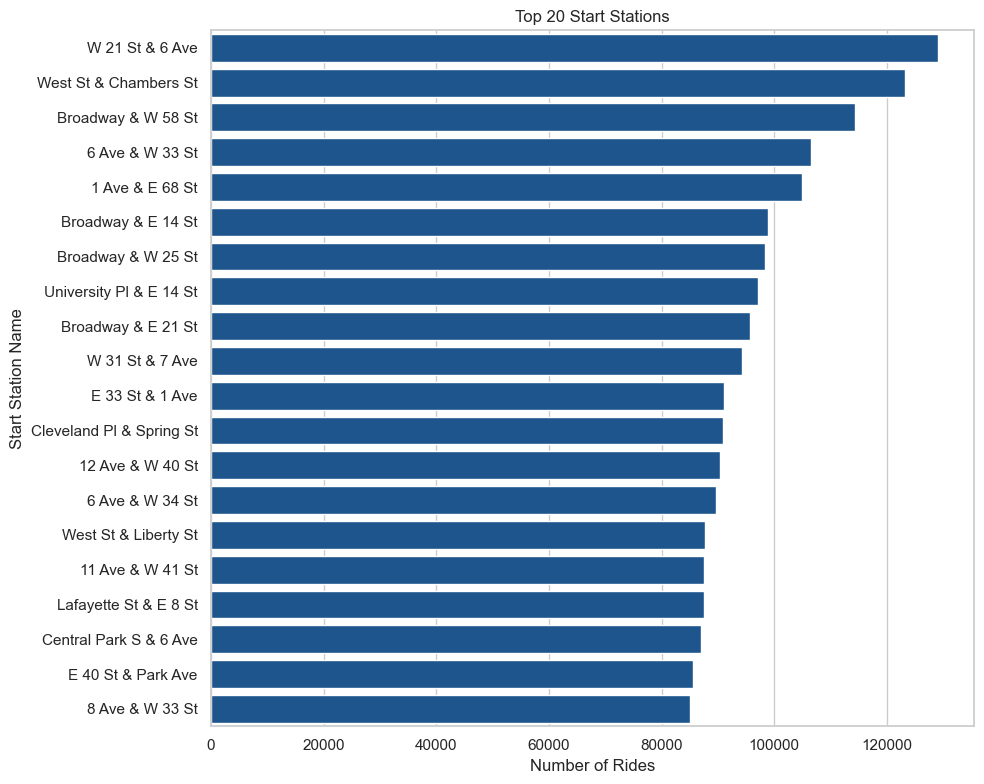

In [20]:
# Check if the palette has enough colors
if len(sns.color_palette()) < 20:
    plt.figure(figsize=(10, 8))
    with sns.color_palette("Blues_r"):
        sns.barplot(data=df_top20, x='value', y='start_station_name').set_title("Top 20 Start Stations")
else:
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df_top20, x='value', y='start_station_name').set_title("Top 20 Start Stations")

# Provide appropriate labels and then show the barplot
plt.xlabel('Number of Rides')
plt.ylabel('Start Station Name')
plt.tight_layout()
plt.show()

In [30]:
# Step 5: Create a dual line chart for bike rides and temperature
# Prepare 'date' column and Convert 'started_at' to datetime
df['started_at'] = pd.to_datetime(df['started_at'])

In [32]:
# Filter only 2022 rides (To include only the data from 2022)
df = df[df['started_at'].dt.year == 2022]

In [34]:
# Keep only the date part (strip time)
df['started_at'] = df['started_at'].dt.date

In [36]:
# Group Average Temperature Per Day
df_temp_grouped = df.groupby('started_at')['avgTemp'].mean().reset_index()

In [38]:
df_temp_grouped.rename(columns={'started_at': 'date'}, inplace=True)

In [40]:
# Group Bike Trip Counts Per Day
df_rides_grouped = df.groupby('started_at')['ride_id'].count().reset_index()

In [42]:
df_rides_grouped.rename(columns={'started_at': 'date', 'ride_id': 'bike_rides_daily'}, inplace=True)

In [46]:
# Merge Grouped Temperature and Bike Trips
df_final = pd.merge(df_temp_grouped, df_rides_grouped, on='date')

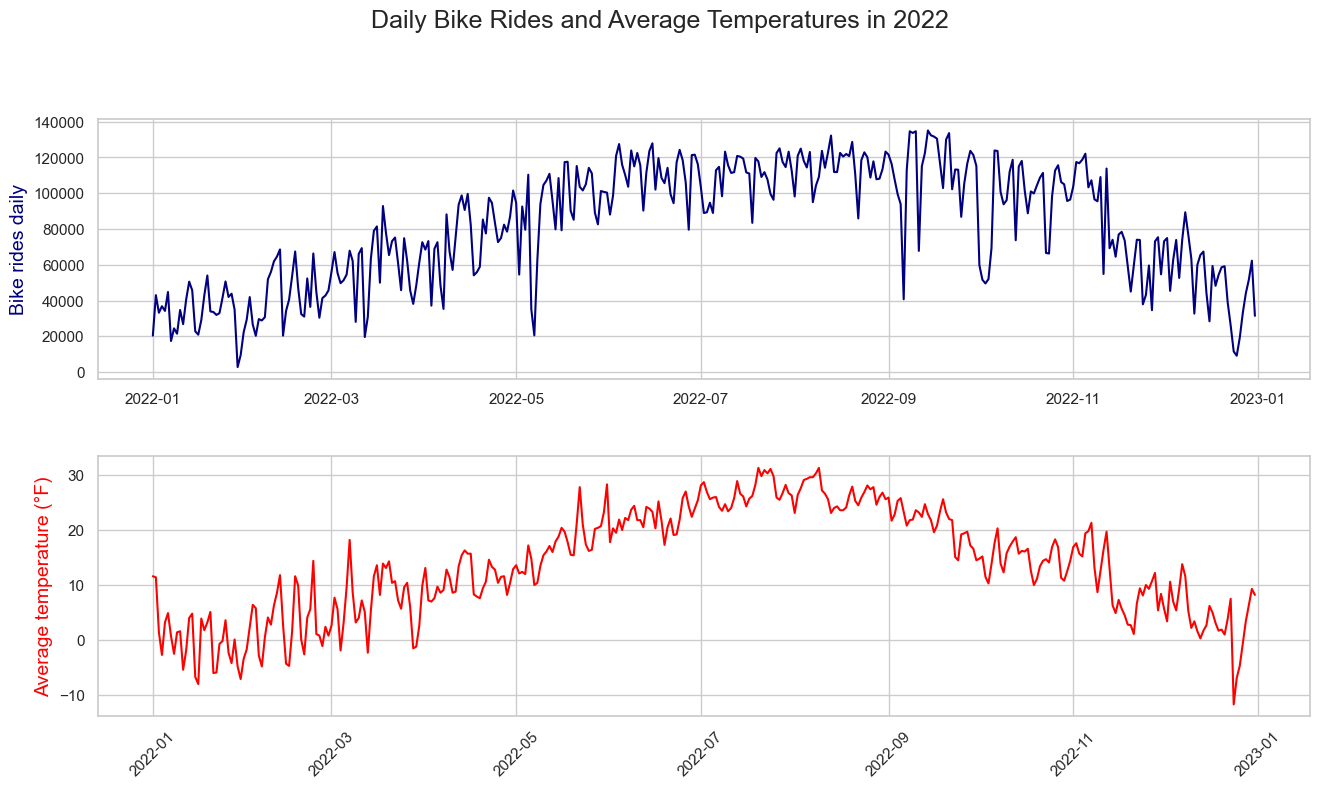

In [48]:
# Create Two Separate Subplots for Bike Rides and Temperature
fig, ax = plt.subplots(2, figsize=(14,8))

# Plot bike rides daily on first subplot
ax[0].plot(df_final['date'], df_final['bike_rides_daily'], color='navy')
ax[0].set_ylabel('Bike rides daily', color='navy', fontsize=14)
ax[0].grid(True)

# Plot average temperatures on second subplot
ax[1].plot(df_final['date'], df_final['avgTemp'], color='red')
ax[1].set_ylabel('Average temperature (°F)', color='red', fontsize=14)
ax[1].grid(True)

# Set a main title for the figure
plt.suptitle('Daily Bike Rides and Average Temperatures in 2022', fontsize=18)

# Layout adjustment and rotate x-axis labels
fig.tight_layout(pad=3.0)
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45)

# Display the figure
plt.show()

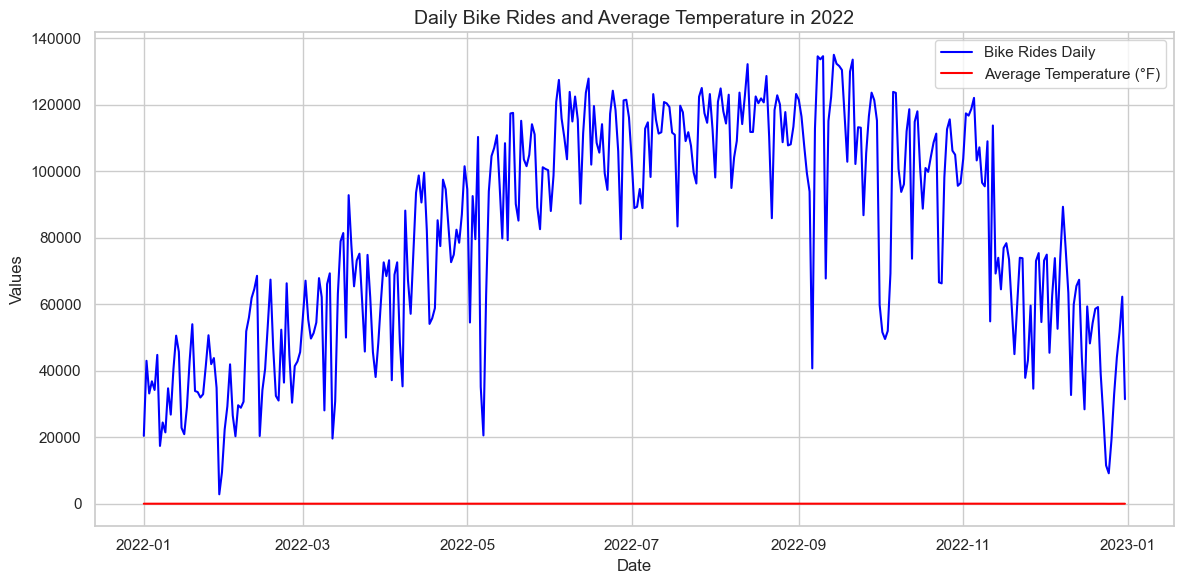

In [50]:
# Plotting Both graphs on one axis
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_final, x='date', y='bike_rides_daily', color='b', label='Bike Rides Daily')
sns.lineplot(data=df_final, x='date', y='avgTemp', color='r', label='Average Temperature (°F)')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.title('Daily Bike Rides and Average Temperature in 2022', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/zl/tcc09dfs4v13063yfphqmzjr0000gn/T/ipykernel_29085/1733228016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rideable_type', y='avgTemp', data=df, palette='Set2')


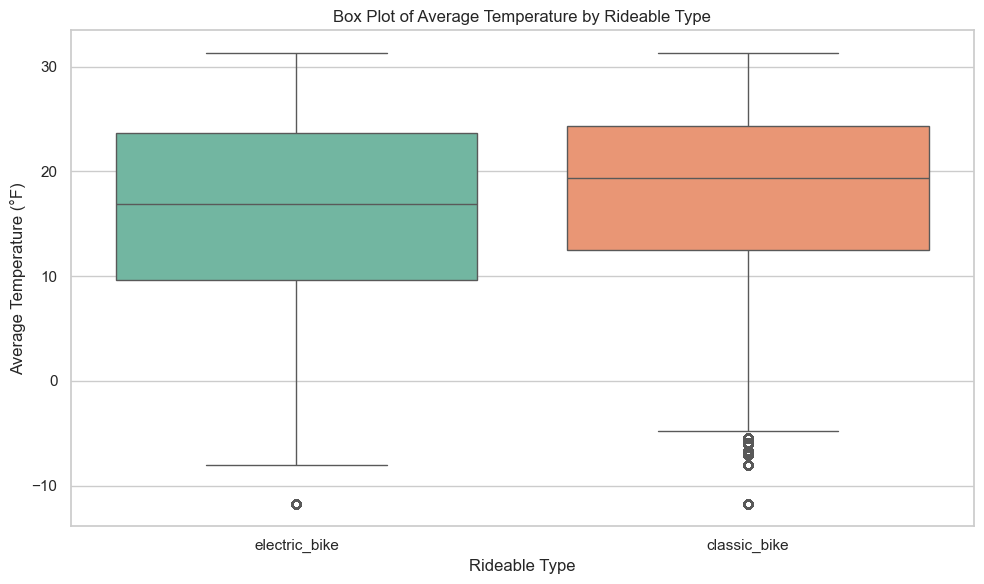

In [56]:
 # Step 6: Create a box plot of a categorical variable
plt.figure(figsize=(10,6))
sns.boxplot(x='rideable_type', y='avgTemp', data=df, palette='Set2')
plt.title('Box Plot of Average Temperature by Rideable Type')
plt.xlabel('Rideable Type')
plt.ylabel('Average Temperature (°F)')
plt.tight_layout()
plt.show()

### Step 6: Box plot analysis
#### Analysis:
- The box plot shows that the distribution of average temperatures is fairly similar across different rideable types.
- There are slight variations in the medians, and some outliers are visible particularly for lower temperatures.
- This suggests that the choice of bike type is not strongly influenced by temperature, although extreme weather days might impact specific types slightly.

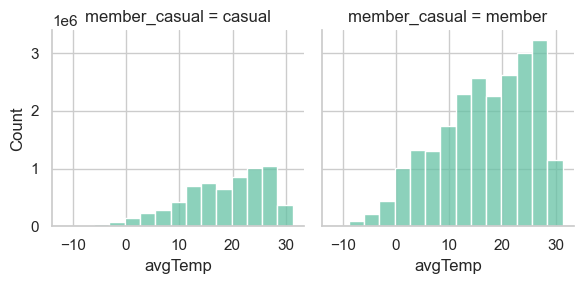

In [60]:
# Step 7: Create a FacetGrid to further analyze
# Using 'member_casual' to facet the data based on ride type
facet = sns.FacetGrid(df, col='member_casual')
facet.map(sns.histplot, 'avgTemp', bins=15)
plt.tight_layout()
plt.show()

### Step 7: FacetGrid analysis
#### Analysis:
- The FacetGrid shows that casual riders tend to ride more during warmer average temperatures compared to members.
- Members seem to ride more consistently across a broader temperature range, indicating different usage patterns between the two groups.